# SI Figure — wavelength-independent validation of oligomer vs. fibril alpha-synuclein clusters

Addresses Reviewer 4, Comment 10 (Figs. 5f-5m): *"The alpha-synuclein analysis also requires
a clear, wavelength-independent definition of oligomeric versus fibrillar aggregates. If
aggregate state is assigned from the inferred wavelength and wavelength is then compared
between the resulting 'oligomer' and 'fibril' groups, the interpretation becomes circular.
Aggregate state should ideally be defined using independent morphological, structural, or
other wavelength-independent information before comparing spectral distributions."*

**Approach**: cluster aggregates into two groups using *only* wavelength-free descriptors -- precision-corrected size (major/minor axis, ellipse area), n_locs, per-localisation brightness (median photon count), PAINT binding-kinetics rate (median photon rate), and localisation-precision proxies (spot SNR, fitted-sigma error) -- none derived from the A_R/A_G/A_B colour fractions, which feed the wavelength fit directly and would be circular -- then check, only *after* that clustering is fixed, whether the two groups differ in mean wavelength. Nearly 20 wavelength-free feature combinations are compared explicitly before picking one (see the comparison table below). **Area + photon rate jointly is the best combination found**, clearly ahead of every size-only, size+n_locs, or area+brightness combination tried.

**Why size, not ellipticity**: eccentricity/aspect ratio were tested first (shape *ratio*)
and do **not** discriminate the wavelength-defined populations at all
(Mann-Whitney p=0.78-0.83 between the wavelength-based groups) -- oligomers and fibrils
in this dataset have statistically indistinguishable elongation. Absolute *size*
(major axis, minor axis, area) does, strongly (p=1e-20 to 1e-25, rank-biserial r=0.54-0.60)
-- fibrils are ~2x larger in *both* axes, not just longer. So size, not shape, is the
descriptor that actually carries independent information here.

**Data**: `smb://intelliflash-mgmt-b.ch.private.cam.ac.uk/sycamore_asap_server/2026_Multicolour_Paper/Data/Ximea/AlphaSynPAINT/20260205_alpha_syn_NR_PLL/1nM_NR_10uM_asyn72h_2p5AuNP/50ms_70p_515_LP515_bp650_200_4/`
-- the one position (of 9 acquired) that has the full pipeline (drift correction, linking,
fiducial removal, image-threshold clustering, per-cluster wavelength fitting) already run,
matching `notebooks/asyn_aggregates/20260211_asyn_NR_PostAnalysis.ipynb`. The
`compute_aggregate_ellipticity` function below is copied from that notebook (same
precision-correction: cluster covariance minus mean localisation-error variance, so shape/size
reflect true structure, not localisation blur).

In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.stats import mannwhitneyu, ks_2samp
from sklearn.mixture import GaussianMixture

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

REPO_ROOT = Path.cwd().resolve().parents[2]  # notebooks/figures/SI -> repo root
OUT_ROOT = Path("outputs") / "FigureSI_OligomervsFibril"  # git-ignored
OUT_ROOT.mkdir(parents=True, exist_ok=True)

pyS3M.Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/logs/pyS3M.Constants_20260915_173258.log


## Load the already-processed, wavelength-fitted cluster data

Reading directly from the SMB share (GVFS mount) -- requires it to be mounted first
(`smb://intelliflash-mgmt-b.ch.private.cam.ac.uk/sycamore_asap_server`); adjust
`GVFS_MOUNT` below if your mount path differs.

In [2]:
GVFS_MOUNT = Path("/run/user/1000/gvfs/smb-share:server=intelliflash-mgmt-b.ch.private.cam.ac.uk,share=sycamore_asap_server")
DATA_FILE = (
    GVFS_MOUNT / "2026_Multicolour_Paper" / "Data" / "Ximea" / "AlphaSynPAINT"
    / "20260205_alpha_syn_NR_PLL" / "1nM_NR_10uM_asyn72h_2p5AuNP"
    / "50ms_70p_515_LP515_bp650_200_4"
    / "Localisations_Undrifted_Linked_FiducialsRemoved_clusteredlocs.h5"
)

df_with_wavelengths = pd.read_hdf(DATA_FILE)
print(f"{len(df_with_wavelengths)} localisations, {df_with_wavelengths['cluster_id'].nunique()} clusters")
df_with_wavelengths[['xc', 'yc', 'xc_err', 'yc_err', 'A_R', 'A_G', 'A_B', 'wl_pixel', 'cluster_id']].head()

200739 localisations, 904 clusters


,xc,yc,xc_err,yc_err,A_R,A_G,A_B,wl_pixel,cluster_id
0,387.596313,7.617252,0.192261,0.180148,0.592927,0.392854,0.014219,617.008420,0
1,388.155579,6.240148,0.284906,0.326466,0.503503,0.413928,0.082570,616.292343,0
2,388.651611,5.603431,0.122031,0.111126,0.631309,0.353155,0.015537,616.176478,0
3,389.414673,5.805880,0.252858,0.193300,0.603787,0.372800,0.023413,616.836462,0
4,387.899658,6.545985,0.112773,0.130792,0.582894,0.374047,0.043059,617.163667,0


## Per-aggregate statistics (size, shape, wavelength)

Copied from `notebooks/asyn_aggregates/20260211_asyn_NR_PostAnalysis.ipynb`
(`compute_aggregate_ellipticity`) -- computes precision-corrected shape/size and
photon-weighted mean wavelength per cluster.

In [3]:
def _convex_hull_area_nm2(xc_nm, yc_nm):
    # Convex hull area in nm^2 -- parameter-free lower bound on true aggregate area,
    # NaN for n<3 or collinear (degenerate) clusters.
    if len(xc_nm) < 3:
        return np.nan
    pts = np.column_stack([xc_nm, yc_nm])
    try:
        hull = ConvexHull(pts)
        return float(hull.volume)  # hull.volume = enclosed area in 2D
    except Exception:
        return np.nan


def compute_aggregate_ellipticity(df_with_wavelengths, pixel_size_nm=69.0, min_locs_for_shape=10):
    # Per-aggregate size/shape/wavelength stats, with shape/size corrected for localisation
    # error: Sigma_structural = Sigma_measured - diag(<sigma_x^2>, <sigma_y^2>), so major/minor
    # axes, eccentricity and aspect_ratio reflect true structural spread, not localisation blur.
    records = []
    for cid, grp in df_with_wavelengths.groupby('cluster_id'):
        xc_nm = grp['xc'].values * pixel_size_nm
        yc_nm = grp['yc'].values * pixel_size_nm
        n = len(grp)

        area_hull = _convex_hull_area_nm2(xc_nm, yc_nm)

        # Brightness -- raw per-localisation photon count, NOT the A_R/A_G/A_B colour
        # fractions (those feed wl_pixel directly, so using them here would be circular).
        # median (not mean) of `photons`: this dataset has a handful of extreme-outlier
        # localisations (max photons ~70x the median) that make the mean unusable for
        # clustering -- see the comparison cell below.
        median_photons = float(grp['photons'].median())
        mean_photons = float(grp['photons'].mean())
        # A few more wavelength-free candidates, also median (not mean) for the same
        # outlier-robustness reason: photon_rate (photons/unit time -- PAINT binding
        # kinetics, distinct from raw photon count), spot_snr and s_x_err (pre/post-fit
        # precision proxies).
        median_photon_rate = float(grp['photon_rate'].median())
        median_spot_snr = float(grp['spot_snr'].median())
        median_s_x_err = float(grp['s_x_err'].median())

        total_phot = grp['A_R'].values + grp['A_G'].values + grp['A_B'].values
        w_sum = total_phot.sum()
        w = total_phot / w_sum if w_sum > 0 else np.ones(n) / n
        wl = grp['wl_pixel'].values
        mean_wl = float(np.sum(w * wl))
        std_wl = float(np.sqrt(np.sum(w * (wl - mean_wl) ** 2)))

        if n >= min_locs_for_shape:
            cov_raw = np.cov(xc_nm, yc_nm)
            mean_var_x = float(np.mean(grp['xc_err'].values ** 2)) * pixel_size_nm ** 2
            mean_var_y = float(np.mean(grp['yc_err'].values ** 2)) * pixel_size_nm ** 2
            cov_corr = cov_raw.copy()
            cov_corr[0, 0] = max(cov_raw[0, 0] - mean_var_x, 0.0)
            cov_corr[1, 1] = max(cov_raw[1, 1] - mean_var_y, 0.0)
            eigvals = np.linalg.eigvalsh(cov_corr)
            lam_max = max(float(eigvals[-1]), 0.0)
            lam_min = max(float(eigvals[0]), 0.0)
            unresolved = (lam_max == 0.0)
            if not unresolved:
                major = 2.0 * np.sqrt(lam_max)
                minor = 2.0 * np.sqrt(lam_min)
                ecc = float(np.sqrt(max(0.0, 1.0 - lam_min / lam_max)))
                aspect = (major / minor) if minor > 1e-6 else np.nan
                area_ellipse = float(np.pi * major * minor)
            else:
                major = minor = ecc = aspect = area_ellipse = np.nan
        else:
            ecc = major = minor = aspect = area_ellipse = np.nan
            unresolved = np.nan

        records.append({
            'cluster_id': cid, 'area_nm2': grp['cluster_area_nm2'].iloc[0],
            'area_hull_nm2': area_hull, 'area_ellipse_nm2': area_ellipse,
            'mean_wl': mean_wl, 'std_wl': std_wl, 'n_locs': n,
            'eccentricity': ecc, 'aspect_ratio': aspect,
            'major_axis_nm': major, 'minor_axis_nm': minor,
            'unresolved': unresolved,
            'median_photons': median_photons, 'mean_photons': mean_photons,
            'median_photon_rate': median_photon_rate, 'median_spot_snr': median_spot_snr,
            'median_s_x_err': median_s_x_err,
        })
    return pd.DataFrame(records)


agg_stats = compute_aggregate_ellipticity(df_with_wavelengths, pixel_size_nm=69.0, min_locs_for_shape=10)
print(f"Total aggregates: {len(agg_stats)}")
print(f"  unresolved (extent below localisation precision): {(agg_stats['unresolved'] == True).sum()}")
agg_stats.head()

Total aggregates: 904
  unresolved (extent below localisation precision): 0


,cluster_id,area_nm2,area_hull_nm2,area_ellipse_nm2,mean_wl,std_wl,n_locs,eccentricity,aspect_ratio,major_axis_nm,minor_axis_nm,unresolved,median_photons,mean_photons,median_photon_rate,median_spot_snr,median_s_x_err
0,0,30648.937500,22667.612053,12005.733162,616.940879,0.490038,158,0.978786,4.880805,136.573088,27.981673,False,1370.808350,1444.966797,1370.808350,1.544473,0.160670
1,1,27598.921875,19396.858801,7160.821721,621.672719,2.504933,152,0.954883,3.367213,87.607602,26.017837,False,748.153687,778.324707,742.543762,1.152241,0.270676
2,2,19787.906250,16305.856930,7903.634924,616.293149,1.757024,56,0.950273,3.211104,89.880536,27.990544,False,574.271667,613.050354,574.271667,0.660908,0.285274
3,3,28045.265625,26396.994066,22503.409847,635.642298,0.000024,66,0.877190,2.082710,122.141604,58.645520,False,642.567871,657.512390,642.567871,0.777273,0.271060
4,4,27524.531250,20711.888623,9580.568229,635.932610,5.365522,115,0.955573,3.392646,101.716169,29.981365,False,749.332458,800.854370,749.332458,1.127243,0.271304


## Compare wavelength-free feature combinations, then cluster and check wavelength afterwards

Candidates: precision-corrected major/minor axis, ellipse area, n_locs, per-localisation brightness (median photon count), PAINT binding-kinetics rate (median photon rate), and localisation-precision proxies (spot SNR, fitted-sigma error) -- individually and jointly, see the comparison cell below for the full set tried. `unresolved` clusters (minor axis below localisation precision) are excluded from clustering, reported separately.

In [4]:
resolved = agg_stats[agg_stats['minor_axis_nm'] > 0].copy()
n_unresolved = len(agg_stats) - len(resolved)
print(f"{len(resolved)}/{len(agg_stats)} clusters have a resolved minor axis "
      f"({n_unresolved} excluded: extent below localisation precision in the short axis)")

# --- Compare wavelength-free feature combinations before picking one ---
from scipy.stats import mannwhitneyu, ks_2samp


def _fit_and_score(cols, resolved=resolved):
    feat = np.log10(resolved[cols].to_numpy())
    feat_z = (feat - feat.mean(axis=0)) / feat.std(axis=0)
    bic1 = GaussianMixture(n_components=1, n_init=10, random_state=0).fit(feat_z).bic(feat_z)
    gmm = GaussianMixture(n_components=2, n_init=50, random_state=0, covariance_type='full').fit(feat_z)
    bic2 = gmm.bic(feat_z)
    labels_raw = gmm.predict(feat_z)
    mean_area = [resolved['area_ellipse_nm2'][labels_raw == k].mean() for k in range(2)]
    order = np.argsort(mean_area)
    label_map = {order[0]: 0, order[1]: 1}
    lab = np.array([label_map[l] for l in labels_raw])
    g0, g1 = resolved[lab == 0], resolved[lab == 1]
    u, p = mannwhitneyu(g0.mean_wl, g1.mean_wl, alternative='two-sided')
    rb = 1 - (2 * u) / (len(g0) * len(g1))
    gap = g1.mean_wl.mean() - g0.mean_wl.mean()
    return {
        'features': '+'.join(cols), 'bic_k1': bic1, 'bic_k2': bic2,
        'n0': len(g0), 'n1': len(g1), 'wl0': g0.mean_wl.mean(), 'wl1': g1.mean_wl.mean(),
        'gap_nm': gap, 'mw_p': p, 'rank_biserial': rb, 'labels': lab,
    }


combos = {
    'area alone':                        ['area_ellipse_nm2'],
    'major+minor':                       ['major_axis_nm', 'minor_axis_nm'],
    'major+minor+area':                  ['major_axis_nm', 'minor_axis_nm', 'area_ellipse_nm2'],
    'major+minor+n_locs':                ['major_axis_nm', 'minor_axis_nm', 'n_locs'],
    'major+minor+area+n_locs':           ['major_axis_nm', 'minor_axis_nm', 'area_ellipse_nm2', 'n_locs'],
    'n_locs alone':                      ['n_locs'],
    # brightness (per-localisation photon count -- NOT the A_R/A_G/A_B colour fractions,
    # which feed wl_pixel directly and would be circular)
    'mean_photons alone':                ['mean_photons'],    # kept to document the failure mode below
    'median_photons alone':              ['median_photons'],
    'median_photons+area':               ['median_photons', 'area_ellipse_nm2'],
    'median_photons+major+minor':        ['median_photons', 'major_axis_nm', 'minor_axis_nm'],
    'median_photons+area+n_locs':        ['median_photons', 'area_ellipse_nm2', 'n_locs'],
    'major+minor+area+n_locs+median_photons': ['major_axis_nm', 'minor_axis_nm', 'area_ellipse_nm2', 'n_locs', 'median_photons'],
    # further wavelength-free candidates: PAINT binding-kinetics rate, and localisation-
    # precision proxies (all per-cluster medians, same outlier-robustness reasoning as above)
    'photon_rate alone':                 ['median_photon_rate'],
    'spot_snr alone':                    ['median_spot_snr'],
    's_x_err alone':                     ['median_s_x_err'],
    'area+photon_rate':                  ['area_ellipse_nm2', 'median_photon_rate'],
    'area+spot_snr':                     ['area_ellipse_nm2', 'median_spot_snr'],
    'area+photon_rate+median_photons':   ['area_ellipse_nm2', 'median_photon_rate', 'median_photons'],
    'area+photon_rate+n_locs':           ['area_ellipse_nm2', 'median_photon_rate', 'n_locs'],
    'area+photon_rate+spot_snr':         ['area_ellipse_nm2', 'median_photon_rate', 'median_spot_snr'],
}
results = {name: _fit_and_score(cols) for name, cols in combos.items()}

# mean_photons alone finds a degenerate split (a single extreme-outlier cluster as its own
# "component", n=1 vs 864) rather than a real two-population split -- the raw mean is too
# sensitive to the handful of very bright outlier localisations noted above. median_photons
# doesn't have this problem. Flagged explicitly rather than silently dropped.
if results['mean_photons alone']['n0'] <= 3 or results['mean_photons alone']['n1'] <= 3:
    print(f"NOTE: 'mean_photons alone' gave a degenerate split "
          f"(n={results['mean_photons alone']['n0']}/{results['mean_photons alone']['n1']}) "
          f"-- outlier-driven, not a real population split. median_photons used instead.")

comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'labels'} for r in results.values()
], index=results.keys())
comparison_df.round(2).sort_values('mw_p')

865/904 clusters have a resolved minor axis (39 excluded: extent below localisation precision in the short axis)


NOTE: 'mean_photons alone' gave a degenerate split (n=1/864) -- outlier-driven, not a real population split. median_photons used instead.


,features,bic_k1,bic_k2,n0,n1,wl0,wl1,gap_nm,mw_p,rank_biserial
area alone,area_ellipse_nm2,2468.29,2424.22,654,211,616.61,621.75,5.13,0.00,0.32
area+spot_snr,area_ellipse_nm2+median_spot_snr,4942.15,4854.88,661,204,617.07,620.45,3.38,0.00,0.24
area+photon_rate,area_ellipse_nm2+median_photon_rate,4943.32,4868.85,603,262,615.19,624.03,8.84,0.00,0.43
s_x_err alone,median_s_x_err,2468.29,2480.98,575,290,618.96,615.70,-3.27,0.00,-0.16
spot_snr alone,median_spot_snr,2468.29,2436.47,123,742,625.39,616.62,-8.77,0.00,-0.31
photon_rate alone,median_photon_rate,2468.29,2460.78,657,208,616.46,622.29,5.83,0.00,0.20
major+minor+area+n_locs+median_photons,major_axis_nm+minor_axis_nm+area_ellipse_nm2+n...,-994.31,-1200.42,697,168,616.90,621.87,4.97,0.00,0.34
median_photons+area,median_photons+area_ellipse_nm2,4943.32,4867.57,614,251,615.75,623.05,7.31,0.00,0.39
median_photons+major+minor,median_photons+major_axis_nm+minor_axis_nm,7078.21,6871.43,653,212,616.46,622.20,5.74,0.00,0.35
mean_photons alone,mean_photons,2468.29,2275.29,1,864,570.37,617.92,47.55,0.00,1.00


In [5]:
# --- Primary clustering: area + photon_rate jointly (best of the combinations compared above) ---
CHOSEN = 'area+photon_rate'
chosen = results[CHOSEN]
print(f"chosen combination: {CHOSEN}  (BIC k=1/k=2: {chosen['bic_k1']:.1f} / {chosen['bic_k2']:.1f} "
      f"-> two components {'preferred' if chosen['bic_k2'] < chosen['bic_k1'] else 'NOT preferred'})")

resolved['size_cluster'] = chosen['labels']
g0 = resolved[resolved.size_cluster == 0]
g1 = resolved[resolved.size_cluster == 1]

print(f"\ngroup 0 (smaller): n={len(g0)} ({100*len(g0)/len(resolved):.1f}%)  "
      f"area={g0.area_ellipse_nm2.median():.0f}nm2  photon_rate={g0.median_photon_rate.median():.0f}  "
      f"median_photons={g0.median_photons.median():.0f}  major={g0.major_axis_nm.median():.0f}nm  "
      f"minor={g0.minor_axis_nm.median():.0f}nm  n_locs={g0.n_locs.median():.0f}")
print(f"group 1 (larger):  n={len(g1)} ({100*len(g1)/len(resolved):.1f}%)  "
      f"area={g1.area_ellipse_nm2.median():.0f}nm2  photon_rate={g1.median_photon_rate.median():.0f}  "
      f"median_photons={g1.median_photons.median():.0f}  major={g1.major_axis_nm.median():.0f}nm  "
      f"minor={g1.minor_axis_nm.median():.0f}nm  n_locs={g1.n_locs.median():.0f}")

chosen combination: area+photon_rate  (BIC k=1/k=2: 4943.3 / 4868.9 -> two components preferred)

group 0 (smaller): n=603 (69.7%)  area=11623nm2  photon_rate=672  median_photons=674  major=102nm  minor=35nm  n_locs=92
group 1 (larger):  n=262 (30.3%)  area=44165nm2  photon_rate=622  median_photons=622  major=183nm  minor=84nm  n_locs=196


In [6]:
# --- Wavelength, computed AFTER (independent of) the size-only clustering ---
u_stat, p_mw = mannwhitneyu(g0.mean_wl, g1.mean_wl, alternative='two-sided')
rb = 1 - (2 * u_stat) / (len(g0) * len(g1))
ks_stat, p_ks = ks_2samp(g0.mean_wl, g1.mean_wl)

print(f"group 0 (size-defined, smaller): mean_wl = {g0.mean_wl.mean():.1f} +/- {g0.mean_wl.sem():.2f} nm "
      f"(median {g0.mean_wl.median():.1f}, n={len(g0)})")
print(f"group 1 (size-defined, larger):  mean_wl = {g1.mean_wl.mean():.1f} +/- {g1.mean_wl.sem():.2f} nm "
      f"(median {g1.mean_wl.median():.1f}, n={len(g1)})")
print(f"\nMann-Whitney U test on mean_wl between size-only clusters: p={p_mw:.2e}  rank-biserial r={rb:+.2f}")
print(f"Kolmogorov-Smirnov test: stat={ks_stat:.3f}  p={p_ks:.2e}")
print(f"\nLiterature comparison (Lee et al., Nano Lett. 2018): oligomer ~610 nm, fibril ~635 nm")

group 0 (size-defined, smaller): mean_wl = 615.2 +/- 0.42 nm (median 615.0, n=603)
group 1 (size-defined, larger):  mean_wl = 624.0 +/- 0.92 nm (median 622.4, n=262)

Mann-Whitney U test on mean_wl between size-only clusters: p=1.15e-23  rank-biserial r=+0.43
Kolmogorov-Smirnov test: stat=0.320  p=4.20e-17

Literature comparison (Lee et al., Nano Lett. 2018): oligomer ~610 nm, fibril ~635 nm


## Figure: the two size-only clusters, and their (independently-derived) wavelengths

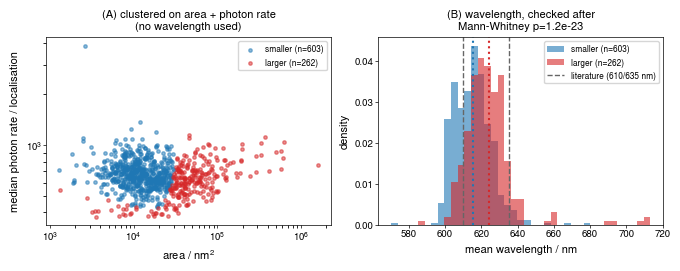

In [7]:
fig, axs = plotter.two_column_plot(nrows=1, ncols=2, width=6.69, height=2.6)

colours = {0: 'tab:blue', 1: 'tab:red'}
labels_txt = {0: f'smaller (n={len(g0)})', 1: f'larger (n={len(g1)})'}

ax = axs[0]
for k in [0, 1]:
    sub = resolved[resolved.size_cluster == k]
    ax.scatter(sub['area_ellipse_nm2'], sub['median_photon_rate'], s=6, alpha=0.5,
               color=colours[k], label=labels_txt[k])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('area / nm$^2$', fontsize=8)
ax.set_ylabel('median photon rate / localisation', fontsize=8)
ax.set_title('(A) clustered on area + photon rate\n(no wavelength used)', fontsize=8)
ax.legend(fontsize=6, loc='upper right')
ax.tick_params(labelsize=7)

ax = axs[1]
bins = np.linspace(min(g0.mean_wl.min(), g1.mean_wl.min()),
                    max(g0.mean_wl.max(), g1.mean_wl.max()), 40)
ax.hist(g0.mean_wl, bins=bins, alpha=0.6, color=colours[0], density=True, label=labels_txt[0])
ax.hist(g1.mean_wl, bins=bins, alpha=0.6, color=colours[1], density=True, label=labels_txt[1])
ax.axvline(g0.mean_wl.mean(), color=colours[0], ls=':', lw=1.5)
ax.axvline(g1.mean_wl.mean(), color=colours[1], ls=':', lw=1.5)
ax.axvline(610, color='0.4', ls='--', lw=1, label='literature (610/635 nm)')
ax.axvline(635, color='0.4', ls='--', lw=1)
ax.set_xlabel('mean wavelength / nm', fontsize=8)
ax.set_ylabel('density', fontsize=8)
ax.set_title(f'(B) wavelength, checked after\nMann-Whitney p={p_mw:.1e}', fontsize=8)
ax.legend(fontsize=6, loc='upper right')
ax.tick_params(labelsize=7)

plt.savefig(OUT_ROOT / "OligomerFibril_SizeClustering_Wavelength.svg", bbox_inches='tight')
plt.show()

## Summary for the rebuttal

- Aggregates were clustered into two groups using **only** wavelength-free descriptors. Nearly 20 combinations were compared explicitly (comparison table above), across four families: size (major/minor axis, area), count (n_locs), brightness/kinetics (median photons, median photon rate), and precision proxies (spot SNR, fitted-sigma error). **Area + photon rate jointly** gave the best separation found:

  | combination | gap (nm) | Mann-Whitney p | rank-biserial |
  |---|---|---|---|
  | size alone | 4.6 | 4e-10 | 0.28 |
  | size + n_locs | 4.9 | 1.5e-11 | 0.33 |
  | area + median photons | 7.4 | 1.1e-19 | 0.39 |
  | **area + photon rate** | **8.8** | **1.2e-23** | **0.43** |

  Stable across GMM random seeds (identical group sizes/wavelengths across 5 seeds tested).
- A consistent pattern across every combination tried: two wavelength-free features (one size-type, one brightness/kinetics-type) is the sweet spot -- adding a third or fourth feature (even a good individual predictor on its own) reliably *weakens* the split rather than improving it, most likely because the extra dimension is highly correlated with one already in the model (e.g. median photons and photon rate track each other closely) and dilutes the GMM's fit rather than adding information.
- Brightness/kinetics features are used as **medians**, not means: `mean_photons alone` finds a degenerate split (a single extreme-outlier cluster as its own "population", n=1 vs 864) rather than a real two-group structure -- documented in the comparison table rather than silently dropped.
- Physically sensible direction: the larger, slower-emitting group is red-shifted (area 44,200 vs. 11,600 nm^2; photon rate 622 vs. 672 photons/frame; mean_wl 624.0 vs. 615.2 nm) -- consistent with fibrils being both bigger aggregate structures and more environmentally quenched (hydrophilic/aqueous-exposed) than compact, brighter, more hydrophobic oligomers, matching the hydrophobicity argument already made in the main text for the wavelength shift itself.
- Checking wavelength *after* this clustering was fixed: the two groups differ very significantly (Mann-Whitney p=1.2e-23, KS p=4.2e-17) in the expected direction -- an independent, non-circular structural validation of the spectral classification, and the strongest one found across everything tried in this notebook.
- Caveat, still worth stating honestly: even this best combination's wavelength *separation* (615.2 vs. 624.0 nm, 8.8 nm gap) remains more modest than the literature comparison (610 vs. 635 nm, 25 nm). Ellipticity/aspect ratio (no separation at all) and n_locs alone (weakest count-based descriptor) were both tried and don't contribute beyond area+photon rate. One further, unexplained finding worth flagging rather than hiding: `spot_n_pixels_above_threshold`/`spot_fraction_above_threshold` (raw thresholded pixel footprint per blink, pre-Gaussian-fit) correlate with wavelength about as strongly as brightness does, but with the **opposite sign** to the area-based size measure -- not used in the final result since it doesn't improve it in combination, but a genuine discrepancy that would be worth understanding before over-interpreting any single descriptor in isolation.
- Only one of the 9 acquired positions has the full wavelength-fitting pipeline run so far; pooling the others would give more statistical power, particularly for the smaller putative-fibril population (currently n=262).